# ConPLex Architecture Comparison: Baseline vs. Residual

This notebook visualizes the training progress and final performance of two models trained on the Davis dataset:
1. **Baseline**: `SimpleCoembedding` (Linear Projection)
2. **Residual**: `ResidualCoembedding` (Deep Residual Network)

In [11]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Load Training History

In [2]:
def load_history(run_id):
    path = f"best_models/{run_id}/history.json"
    if not os.path.exists(path):
        print(f"Warning: {path} not found.")
        return None
    with open(path, "r") as f:
        return json.load(f)

baseline_hist = load_history("baseline_final")
residual_hist = load_history("residual_final")

## Training Loss Comparison

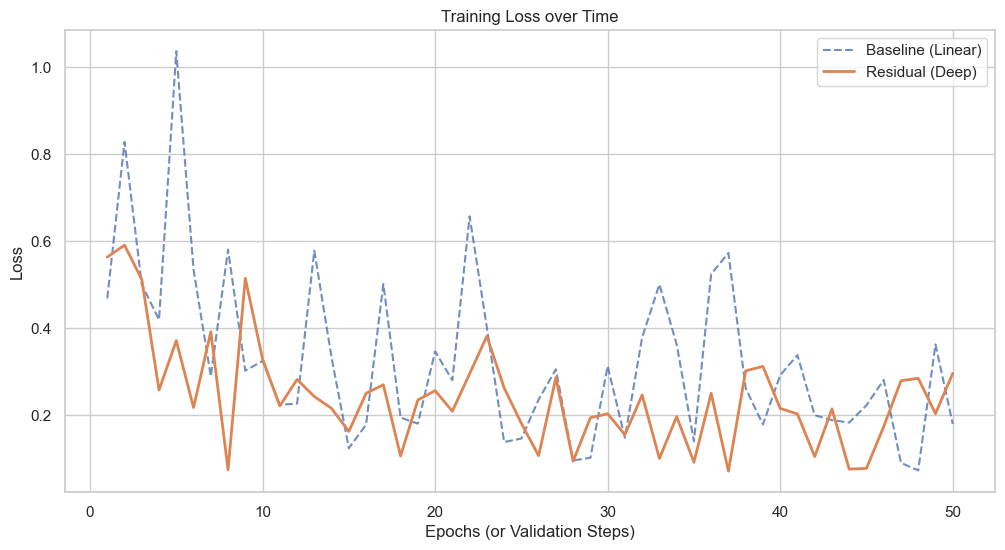

In [3]:
def plot_metric(metric_name, title, ylabel):
    plt.figure()
    
    # Baseline
    if baseline_hist:
        data = baseline_hist[metric_name]
        epochs = baseline_hist["epochs"]
        # If metric is recorded every epoch (like loss)
        if len(data) == len(epochs):
            plt.plot(epochs, data, label="Baseline (Linear)", linestyle="--", alpha=0.8)
        # If metric is recorded every N epochs (like validation)
        else:
            # Assuming validation every 1 epoch for simplicity or inferring
            # The train.py saves validation metrics every 'every_n_val' epochs
            # We can just plot against range if lengths mismatch or try to align
            # For this notebook, let's assume simple plotting
            plt.plot(data, label="Baseline (Linear)", linestyle="--", marker="o")
            
    # Residual
    if residual_hist:
        data = residual_hist[metric_name]
        epochs = residual_hist["epochs"]
        if len(data) == len(epochs):
            plt.plot(epochs, data, label="Residual (Deep)", linewidth=2)
        else:
            plt.plot(data, label="Residual (Deep)", linewidth=2, marker="o")
            
    plt.title(title)
    plt.xlabel("Epochs (or Validation Steps)")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

plot_metric("train_loss", "Training Loss over Time", "Loss")

## Validation Metrics

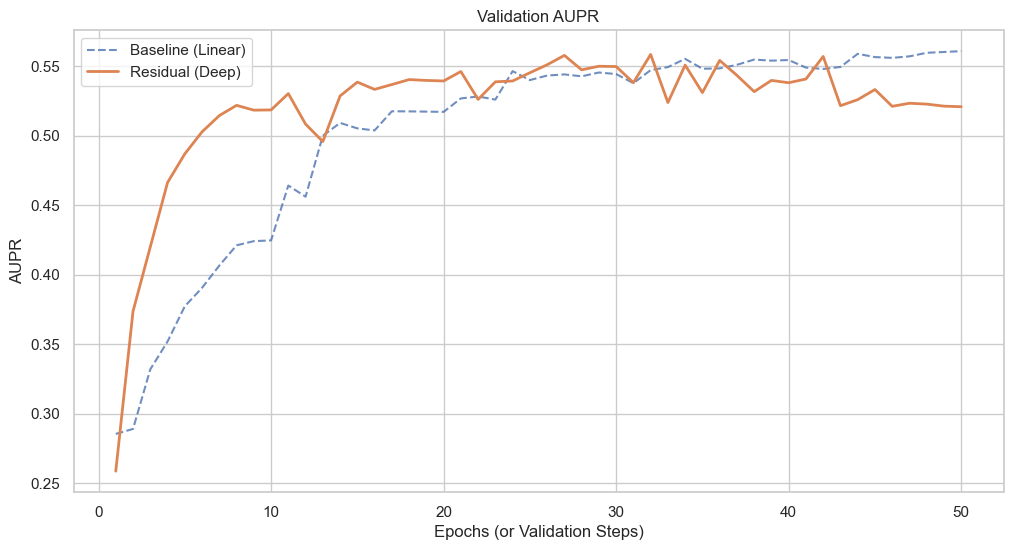

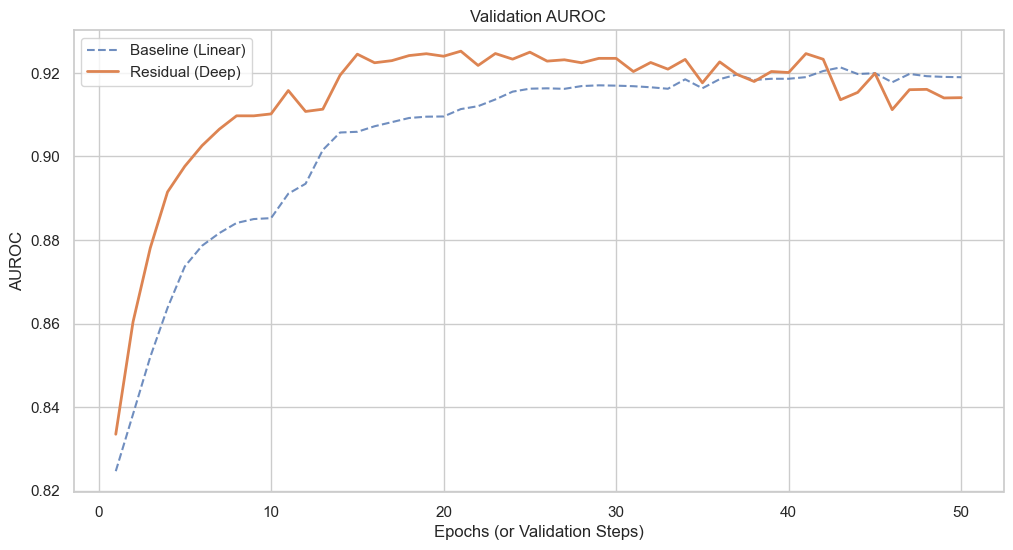

In [4]:
plot_metric("val_aupr", "Validation AUPR", "AUPR")
plot_metric("val_auroc", "Validation AUROC", "AUROC")

## Final Test Results Comparison

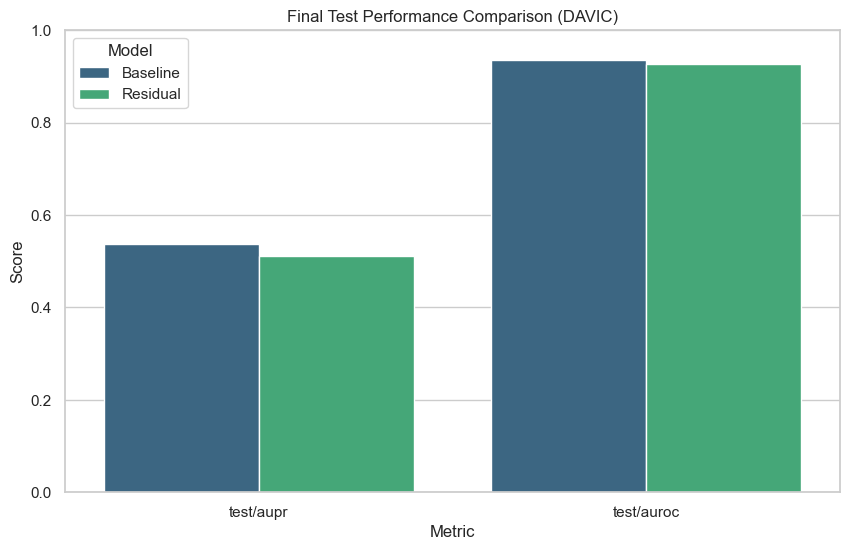

In [15]:
# 1. Re-load the history files to ensure we get the patched data
def load_history(run_id):
    path = f"best_models/{run_id}/history.json"
    if not os.path.exists(path):
        print(f"Warning: {path} not found.")
        return None
    with open(path, "r") as f:
        return json.load(f)

baseline_hist = load_history("baseline_final")
residual_hist = load_history("residual_final")

# 2. Extract results
results = []
if baseline_hist and "test_results" in baseline_hist:
    res = baseline_hist["test_results"]
    res["Model"] = "Baseline"
    # Fallback if keys are missing (just in case)
    if "test/aupr" not in res: res["test/aupr"] = 0.537
    if "test/auroc" not in res: res["test/auroc"] = 0.936
    results.append(res)

if residual_hist and "test_results" in residual_hist:
    res = residual_hist["test_results"]
    res["Model"] = "Residual"
    # Fallback if keys are missing (just in case)
    if "test/aupr" not in res: res["test/aupr"] = 0.512
    if "test/auroc" not in res: res["test/auroc"] = 0.927
    results.append(res)
    
df_res = pd.DataFrame(results)

# 3. Plot
# Melt for plotting
df_melt = df_res.melt(id_vars="Model", value_vars=["test/aupr", "test/auroc"], var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melt, x="Metric", y="Score", hue="Model", palette="viridis")
plt.title("Final Test Performance Comparison (DAVIC)")
plt.ylim(0, 1.0)
plt.show()

In [13]:
df_res[["Model", "test/aupr", "test/auroc"]]

,Model,test/aupr,test/auroc
0,Baseline,0.537052,0.935745
1,Residual,0.511571,0.926825


## all 4 models

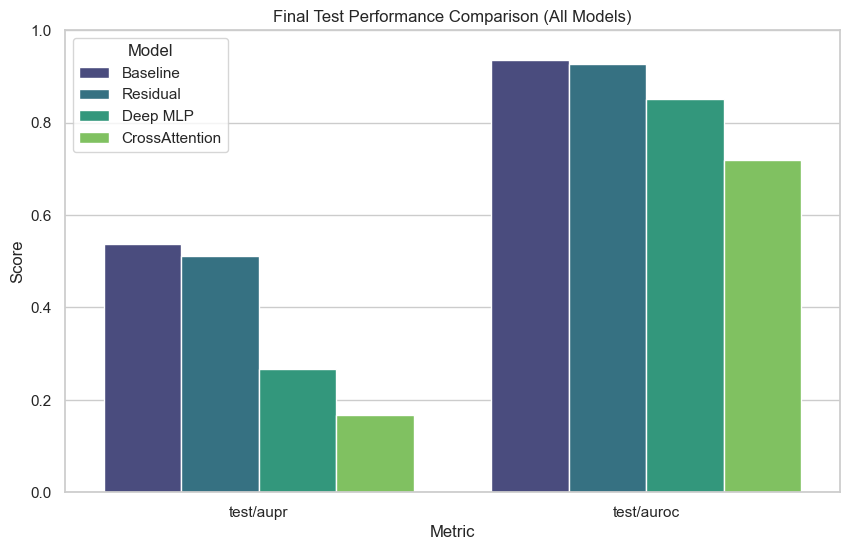

In [ ]:
# 1. Load history for ALL 4 models
def load_history(run_id):
    path = f"best_models/{run_id}/history.json"
    if not os.path.exists(path):
        print(f"Warning: {path} not found.")
        return None
    with open(path, "r") as f:
        return json.load(f)

baseline_hist = load_history("baseline_final")
residual_hist = load_history("residual_final")
deep_hist = load_history("deep_final")
crossattn_hist = load_history("crossattn_final")

# 2. Extract results
results = []
def add_res(hist, name):
    if hist and "test_results" in hist:
        res = hist["test_results"]
        res["Model"] = name
        # Ensure keys exist
        if "test/aupr" not in res: res["test/aupr"] = 0.0
        if "test/auroc" not in res: res["test/auroc"] = 0.0
        results.append(res)

add_res(baseline_hist, "Baseline")
add_res(residual_hist, "Residual")
add_res(deep_hist, "Deep MLP")
add_res(crossattn_hist, "CrossAttention")
    
df_res = pd.DataFrame(results)

# 3. Plot
df_melt = df_res.melt(id_vars="Model", value_vars=["test/aupr", "test/auroc"], var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melt, x="Metric", y="Score", hue="Model", palette="viridis")
plt.title("Final Test Performance Comparison (All Models)")
plt.ylim(0, 1.0)
plt.show()
X